# Clasificación de Letras Escritas a Mano con Perceptrón Multicapa (MLP)

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de esta sesión es diseñar, entrenar y evaluar una red neuronal clásica basada en la arquitectura de **Perceptrón Multicapa (MLP)** para clasificar de manera automática imágenes de letras escritas a mano (del conjunto de datos EMNIST). Analizaremos el impacto de las capas densas, comprenderemos el preprocesamiento de imágenes matriciales y aprenderemos a interpretar los errores del modelo a través de matrices de confusión.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Cargar y estructurar conjuntos de datos complejos utilizando TensorFlow Datasets (TFDS).
2. Aplicar operaciones de normalización y transformación de etiquetas en imágenes 2D.
3. Construir una arquitectura secuencial clásica con capas de aplanado (Flatten) y múltiples capas densas.
4. Evaluar cuantitativamente el desempeño de la red en datos inéditos y graficar curvas de aprendizaje.
5. Diagnosticar patrones de confusión sistemáticos en clasificación de imágenes usando matrices de error.

## Terminología clave (Microglosario)

*   **Clasificación de Imágenes:** Tarea de asignar una etiqueta categórica a una imagen basándose en sus características visuales.
*   **EMNIST (Extended MNIST):** Conjunto de datos académico que contiene imágenes digitalizadas en escala de grises de letras y dígitos escritos a mano.
*   **Aplanado (Flatten):** Proceso de transformar un tensor multidimensional (como una imagen de $28 \times 28$ píxeles) en un único vector continuo unidimensional (de $784$ elementos).
*   **Capa Oculta Densa (Dense Hidden Layer):** Capa intermedia en la cual todas sus neuronas están completamente conectadas con la salida de la capa anterior.
*   **Softmax:** Función de activación aplicada en la capa de salida para convertir las predicciones crudas de la red en un vector de probabilidades que suman exactamente 1.
*   **Matriz de Confusión:** Gráfico bidimensional que confronta la clase real de las muestras con la clase predicha por la red, permitiendo identificar errores recurrentes de clasificación.
*   **Una imagen matricial** (también llamada imagen raster o de mapa de bits) es una imagen representada como una cuadrícula de píxeles, donde cada píxel tiene un valor numérico que representa su color o intensidad.  Diferencia con imagen vectorial: Matricial (raster): Píxeles fijos, Se pixela al ampliar, JPG, PNG
Vectorial: Fórmulas matemáticas, Escala sin perder calidad, SVG, PDF
*   **Un tensor** es simplemente un array multidimensional de números con un shape bien definido.
*   **Keras** Es la API de alto nivel de TensorFlow para construir y entrenar redes neuronales con código simple y legible.

## Perceptrón

Es la unidad más básica de una red neuronal — imita el funcionamiento de una neurona biológica.


### Qué hace en dos pasos

**1. Suma ponderada:**
z = x₁·w₁ + x₂·w₂ + x₃·w₃ + b


**2. Función de activación:**
ŷ = f(z)


### Analogía biológica

| Neurona biológica | Perceptrón |
|---|---|
| Dendritas (reciben señales) | Entradas (x) |
| Sinapsis (fuerza de conexión) | Pesos (w) |
| Cuerpo celular (procesa) | Suma ponderada (Σ) |
| Axón (dispara o no) | Función de activación f(z) |

### Limitación clave

Un perceptrón simple **solo puede clasificar problemas linealmente separables**. No puede aprender el problema XOR, por ejemplo.

Por eso se apilan múltiples perceptrones en capas → **red neuronal multicapa (MLP)**, que puede aprender patrones no lineales complejos.

### En Keras, un perceptrón es simplemente:

```python
keras.layers.Dense(units=1, activation='sigmoid')  # una sola neurona

## 1. Configuración de Dependencias e Importaciones

Comencemos instalando y cargando las herramientas de análisis de datos, visualización y desarrollo de redes neuronales.

In [1]:
print("✦ Instalando librerías complementarias en el sistema...")  # Muestra informacion en consola para verificar el avance o los resultados.
# Mantener la instalación silenciosa para evitar ruido didáctico
!pip install "opencv-python-headless==4.9.0.80" seaborn -q 
#OpenCV      →  leer y preprocesar imágenes de letras (redimensionar, convertir a gris)
#Seaborn     →  visualizar resultados (matriz de confusión, métricas del modelo)
# -q Quiet — suprime la mayor parte del output de instalación

print("✓ Librerías instaladas con éxito.\n")  # Muestra informacion en consola para verificar el avance o los resultados.

import tensorflow as tf  # Framework principal para construir, entrenar y ejecutar redes neuronales.
import tensorflow_datasets as tfds  # Descarga y prepara datasets académicos listos para entrenar modelos (como EMNIST).
import matplotlib.pyplot as plt  # Genera gráficos y visualizaciones de imágenes y métricas de entrenamiento.
import numpy as np  # Operaciones matemáticas eficientes sobre arreglos y matrices multidimensionales.
import math  # Funciones matemáticas básicas como ceil() para calcular la cantidad de pasos por época.
import cv2  # Procesamiento y manipulación de imágenes: redimensionar, convertir espacios de color, leer archivos.
import os  # Interacción con el sistema de archivos: rutas, directorios y variables de entorno.
import seaborn as sns  # Visualizaciones estadísticas avanzadas sobre matplotlib, como mapas de calor (heatmaps).
from sklearn.metrics import confusion_matrix  # Calcula la matriz de confusión para evaluar errores de clasificación por clase.

print("✓ Herramientas de Deep Learning listas para utilizar.")  # 

✦ Instalando librerías complementarias en el sistema...


  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✓ Librerías instaladas con éxito.

✓ Herramientas de Deep Learning listas para utilizar.


## 2. Carga y Exploración de Datos (EMNIST/Letters)

Utilizaremos el dataset EMNIST configurado para la división de letras. Este conjunto agrupa miles de ejemplos de caracteres escritos a mano en escala de grises.

In [ ]:
# Este bloque carga y organiza el conjunto de datos; un modelo aprende a partir de ejemplos; por eso primero se define de 
# donde vienen las imagenes o mediciones y como se separan sus etiquetas.
print("✦ Descargando y cargando el dataset EMNIST/Letters en memoria...")  # Muestra informacion en consola para verificar el avance o los resultados.
print("(Este proceso puede demorar unos minutos la primera vez)")  # Muestra informacion en consola para verificar el avance o los resultados.

# Descargamos los datos y metadatos estructurados
datos, metadatos = tfds.load('emnist/letters', as_supervised=True, with_info=True)  

# Generamos la lista de caracteres reales de forma explícita
nombres_clases = []  # Calcula y guarda el valor en la variable nombres_clases.
for i in range(1, 27):  # Inicia un bucle para recorrer elementos de una coleccion.
    letra = chr(i + ord('a') - 1)  # Calcula y guarda el valor en la variable letra.
    nombres_clases.append(letra)  

cantidad_entrenamiento = metadatos.splits['train'].num_examples  # Calcula y guarda el valor en la variable cantidad_entrenamiento.
cantidad_prueba        = metadatos.splits['test'].num_examples  # Calcula y guarda el valor en la variable cantidad_prueba.
total                  = cantidad_entrenamiento + cantidad_prueba  # Calcula y guarda el valor en la variable total.

print(f"\n✓ Estadísticas del dataset:")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Imágenes de entrenamiento:  {cantidad_entrenamiento:,}")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Imágenes de prueba:         {cantidad_prueba:,}")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • División:                   {100 - cantidad_prueba/total*100:.0f}% / {cantidad_prueba/total*100:.0f}%")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Clases:                     {len(nombres_clases)} letras → {nombres_clases}")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"\n→ Línea base por azar: {1/len(nombres_clases)*100:.1f}%  (1 de cada {len(nombres_clases)} letras)")  # Muestra informacion en consola para verificar el avance o los resultados.

✦ Descargando y cargando el dataset EMNIST/Letters en memoria...
(Este proceso puede demorar unos minutos la primera vez)

✓ Estadísticas del dataset:
  • Imágenes de entrenamiento:  88,800
  • Imágenes de prueba:         14,800
  • División:                   86% / 14%
  • Clases:                     26 letras → ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

→ Línea base por azar: 3.8%  (1 de cada 26 letras)


## 3. Preprocesamiento Didáctico de las Imágenes

Los píxeles de las imágenes de entrada oscilan originalmente entre 0 y 255. Para facilitar la convergencia del entrenamiento de la red, realizaremos dos transformaciones críticas:
1. **Normalización:** Convertir los píxeles a punto flotante en el rango [0, 1].
2. **Ajuste de Etiquetas:** Dado que las etiquetas originales comienzan en 1, les restaremos 1 para adaptarlas al rango de indexación estándar de Python (0 a 25).

In [ ]:
# Este bloque separa datos de entrenamiento, validacion o prueba; evaluar con datos no usados para ajustar pesos permite 
# estimar si el modelo generaliza o si solo memorizo los ejemplos.
def preprocesar_imagen(imagen, etiqueta):  # Define la funcion preprocesar_imagen para reutilizar esta logica mas adelante.
    # Convertimos los valores a flotante y escalamos al rango [0, 1]
    imagen_flotante = tf.cast(imagen, tf.float32)  # Convierte el tipo de dato para operar numericamente con TensorFlow.
    imagen_normalizada = imagen_flotante / 255.0  # Normaliza los pixeles al rango 0-1 para estabilizar el aprendizaje.
    
    # Desplazamos la etiqueta para iniciar el índice en 0
    etiqueta_ajustada = etiqueta - 1  # Calcula y guarda el valor en la variable etiqueta_ajustada.
    
    return imagen_normalizada, etiqueta_ajustada  # Devuelve el resultado calculado por la funcion.

# Aplicamos el mapeo didáctico a los subconjuntos correspondientes
datos_entrenamiento = datos['train'].map(preprocesar_imagen)  # Aplica una funcion de preprocesamiento a cada elemento del dataset.
datos_entrenamiento = datos_entrenamiento.cache()  # Guarda el dataset procesado en memoria para acelerar lecturas posteriores.

datos_pruebas = datos['test'].map(preprocesar_imagen)  # Aplica una funcion de preprocesamiento a cada elemento del dataset.
datos_pruebas = datos_pruebas.cache()  # Guarda el dataset procesado en memoria para acelerar lecturas posteriores.

print("✓ Operaciones de preprocesamiento aplicadas y almacenadas en caché.")  # Muestra informacion en consola para verificar el avance o los resultados.

✓ Operaciones de preprocesamiento aplicadas y almacenadas en caché.


## 4. Visualización de Muestras del Dataset

Es fundamental verificar visualmente la apariencia y consistencia de las imágenes procesadas antes de suministrarlas al modelo.

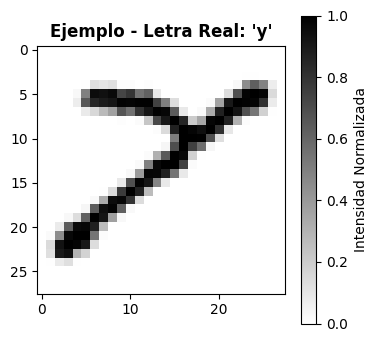

In [13]:
# Extraemos un único ejemplo de entrenamiento para validación visual
for imagen, etiqueta in datos_entrenamiento.take(1):  # Inicia un bucle para recorrer elementos de una coleccion.
    imagen_arreglo = imagen.numpy()  # Calcula y guarda el valor en la variable imagen_arreglo.
    etiqueta_numero = etiqueta.numpy()  # Calcula y guarda el valor en la variable etiqueta_numero.

# Configuramos y dibujamos el gráfico en escala de grises
plt.figure(figsize=(4, 4))  # Crea una figura para graficar resultados o imagenes.
plt.imshow(imagen_arreglo[:, :, 0], cmap=plt.cm.binary)  # Muestra una imagen o mapa de activacion en pantalla.
plt.title(f"Ejemplo - Letra Real: '{nombres_clases[etiqueta_numero]}'", fontsize=12, fontweight="bold")  # Asigna un titulo descriptivo al grafico.
plt.colorbar(label="Intensidad Normalizada")  # Configura o dibuja una visualizacion para interpretar los datos.
plt.grid(False)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.show()  # Renderiza y muestra la visualizacion completa.

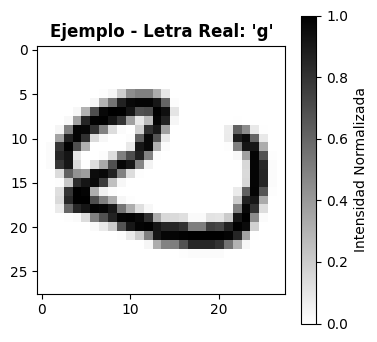

In [14]:
for imagen, etiqueta in datos_entrenamiento.take(2):  # Inicia un bucle para recorrer elementos de una coleccion.
    imagen_arreglo = imagen.numpy()  # Calcula y guarda el valor en la variable imagen_arreglo.
    etiqueta_numero = etiqueta.numpy()  # Calcula y guarda el valor en la variable etiqueta_numero.

# Configuramos y dibujamos el gráfico en escala de grises
plt.figure(figsize=(4, 4))  # Crea una figura para graficar resultados o imagenes.
plt.imshow(imagen_arreglo[:, :, 0], cmap=plt.cm.binary)  # Muestra una imagen o mapa de activacion en pantalla.
plt.title(f"Ejemplo - Letra Real: '{nombres_clases[etiqueta_numero]}'", fontsize=12, fontweight="bold")  # Asigna un titulo descriptivo al grafico.
plt.colorbar(label="Intensidad Normalizada")  # Configura o dibuja una visualizacion para interpretar los datos.
plt.grid(False)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.show()  # Renderiza y muestra la visualizacion completa.

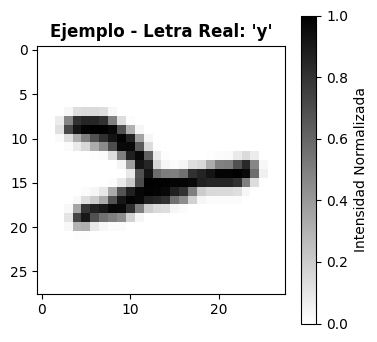

In [15]:
for imagen, etiqueta in datos_entrenamiento.take(3):  # Inicia un bucle para recorrer elementos de una coleccion.
    imagen_arreglo = imagen.numpy()  # Calcula y guarda el valor en la variable imagen_arreglo.
    etiqueta_numero = etiqueta.numpy()  # Calcula y guarda el valor en la variable etiqueta_numero.

# Configuramos y dibujamos el gráfico en escala de grises
plt.figure(figsize=(4, 4))  # Crea una figura para graficar resultados o imagenes.
plt.imshow(imagen_arreglo[:, :, 0], cmap=plt.cm.binary)  # Muestra una imagen o mapa de activacion en pantalla.
plt.title(f"Ejemplo - Letra Real: '{nombres_clases[etiqueta_numero]}'", fontsize=12, fontweight="bold")  # Asigna un titulo descriptivo al grafico.
plt.colorbar(label="Intensidad Normalizada")  # Configura o dibuja una visualizacion para interpretar los datos.
plt.grid(False)  # Configura o dibuja una visualizacion para interpretar los datos.
plt.show()  # Renderiza y muestra la visualizacion completa.

## 5. Diseño y Compilación del Modelo de Red Neuronal (MLP)

Construiremos un Perceptrón Multicapa (MLP). Este modelo toma la matriz 2D de píxeles, la aplana para procesarla como un vector y la proyecta a través de capas ocultas completamente conectadas (Dense).

In [ ]:
# Construimos secuencialmente las capas del modelo
modelo = tf.keras.Sequential([  # Construye un modelo secuencial capa por capa.
    # Capa de Aplanado: Redimensiona de 28x28x1 a un vector plano de 784
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),  # Aplana las caracteristicas para conectarlas con capas densas.
    
    # Primera capa densa intermedia con activación ReLU
    tf.keras.layers.Dense(64, activation='relu'),  # Agrega una capa densa para combinar caracteristicas y producir una salida.
    
    # Segunda capa densa intermedia con activación ReLU
    tf.keras.layers.Dense(64, activation='relu'),  # Agrega una capa densa para combinar caracteristicas y producir una salida.
    
    # Capa de salida: una neurona por letra, activada por Softmax
    tf.keras.layers.Dense(len(nombres_clases), activation='softmax')  # Agrega una capa densa para combinar caracteristicas y producir una salida.
]) 

# Configuración del aprendizaje y las métricas de monitoreo
modelo.compile(  # Configura el optimizador, la perdida y las metricas del modelo.
    optimizer='adam',  # Calcula y guarda el valor en la variable optimizer.
    loss='sparse_categorical_crossentropy',  # Calcula y guarda el valor en la variable loss.
    metrics=['accuracy']  # Referencia la precision como metrica de desempeno del modelo.
)  

print("✓ Modelo secuencial de clasificación diseñado y compilado.")  # Muestra informacion en consola para verificar el avance o los resultados.
modelo.summary()  # Imprime un resumen de capas, salidas y parametros del modelo.

✓ Modelo secuencial de clasificación diseñado y compilado.


c:\Proyectos\rodriguez-carmen-pdi-1c-2026\venv312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,090 (219.10 KB)

 Trainable params: 56,090 (219.10 KB)

 Non-trainable params: 0 (0.00 B)

## Consigna de Lectura e Interpretación

Examinen el tamaño y el número de parámetros de la primera capa oculta (`Dense` de 64 neuronas). ¿Pueden deducir de qué manera se calcula la cantidad de parámetros para esa capa basándose en el vector de entrada aplanado de 784 elementos?

**Respuesta:** La primera capa densa tiene **784 × 64 + 64 = 50 240 parámetros**:
- **784 × 64 pesos:** cada uno de los 784 píxeles del vector de entrada se conecta con cada una de las 64 neuronas.
- **64 sesgos:** cada neurona tiene un sesgo independiente.

**Recuento completo del modelo:**
| Capa | Cálculo | Parámetros |
|---|---|---|
| Flatten → Dense(64) | 784 × 64 + 64 | **50 240** |
| Dense(64) → Dense(64) | 64 × 64 + 64 | **4 160** |
| Dense(64) → Dense(26) | 64 × 26 + 26 | **1 690** |
| **Total** | | **~56 090** |

**Qué implica este diseño:**
- La primera capa domina el total porque recibe el vector más ancho (784 valores). Esa es la ineficiencia estructural de los MLP para imágenes: cada píxel necesita un peso separado para cada neurona, sin importar su posición en la imagen.
- Las CNNs resuelven esto: un filtro 3×3 tiene solo **9 pesos** compartidos que se reutilizan en todas las posiciones, lo que reduce drásticamente el número de parámetros y hace al modelo invariante a traslaciones.

## 6. Configuración de Lotes y Mezcla de Datos

Para realizar un entrenamiento eficiente, organizaremos los ejemplos de entrenamiento en pequeños grupos (lotes o batches). Adicionalmente, barajaremos el conjunto para evitar sesgos por ordenación secuencial.

In [ ]:
TAMANO_LOTE = 32  # Calcula y guarda el valor en la variable TAMANO_LOTE.
total_muestras_entrenamiento = metadatos.splits['train'].num_examples  # Calcula y guarda el valor en la variable total_muestras_entrenamiento.

# Dividimos y mezclamos secuencialmente los datos de entrenamiento
datos_entrenamiento_lotes = datos_entrenamiento.shuffle(total_muestras_entrenamiento)  # Mezcla los ejemplos para evitar sesgos por orden durante el entrenamiento.
datos_entrenamiento_lotes = datos_entrenamiento_lotes.batch(TAMANO_LOTE)  # Agrupa ejemplos en lotes para procesarlos juntos.
datos_entrenamiento_lotes = datos_entrenamiento_lotes.repeat()  # Calcula y guarda el valor en la variable datos_entrenamiento_lotes.

# Los datos de prueba solo requieren agruparse para validación
datos_pruebas_lotes = datos_pruebas.batch(TAMANO_LOTE)  # Agrupa ejemplos en lotes para procesarlos juntos.

print(f"✓ Datos estructurados en lotes de {TAMANO_LOTE} muestras.")  # Muestra informacion en consola para verificar el avance o los resultados.
print(f"  • Total de ejemplos de entrenamiento: {total_muestras_entrenamiento}")  # Muestra informacion en consola para verificar el avance o los resultados.

✓ Datos estructurados en lotes de 32 muestras.
  • Total de ejemplos de entrenamiento: 88800


## 7. Entrenamiento de la Red Neuronal

Alimentaremos al modelo con los lotes preparados para ajustar sus parámetros durante 15 épocas completas.

In [ ]:
EPOCAS = 15  # Calcula y guarda el valor en la variable EPOCAS.
pasos_por_epoca = math.ceil(total_muestras_entrenamiento / TAMANO_LOTE)  

print(f"✦ Iniciando optimización por {EPOCAS} épocas...")  
print("  (Observen cómo el error disminuye y la precisión mejora paso a paso)\n")  

historial = modelo.fit(  
    datos_entrenamiento_lotes,  
    epochs=EPOCAS,  
    steps_per_epoch=pasos_por_epoca  
)  

print("\n✓ Proceso de entrenamiento finalizado correctamente.")  

✦ Iniciando optimización por 15 épocas...
  (Observen cómo el error disminuye y la precisión mejora paso a paso)

Epoch 1/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 671us/step - accuracy: 0.7389 - loss: 0.8883
Epoch 2/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 739us/step - accuracy: 0.8411 - loss: 0.5152
Epoch 3/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 674us/step - accuracy: 0.8631 - loss: 0.4336
Epoch 4/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 698us/step - accuracy: 0.8773 - loss: 0.3848
Epoch 5/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 681us/step - accuracy: 0.8856 - loss: 0.3566
Epoch 6/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 682us/step - accuracy: 0.8907 - loss: 0.3343
Epoch 7/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 667us/step - accuracy: 0.8961 - loss: 0.3157
Epoch 8/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 754us/step - accuracy: 0.8998 - loss: 0.3019
Epoch 9/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 668us/step - accuracy: 0.9034 - loss: 0.2897
Epoch 10/15
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 2s 660us/step - accuracy: 0.9070 

### Resumen didactico del segmento de codigo

**Que se hizo:** se entrena el modelo con los datos disponibles.

**Por que se hizo:** durante el entrenamiento la red corrige sus pesos muchas veces para reducir el error y mejorar sus predicciones.


**Qué muestra la salida por época:**

| Columna | Qué mide | Tendencia esperada |
|---|---|---|
| `loss` | Error en datos de **entrenamiento** | Debe bajar |
| `accuracy` | Aciertos en datos de **entrenamiento** | Debe subir |

**Nota:** este entrenamiento no incluye `validation_data`, por lo que la salida muestra solo métricas de entrenamiento. No hay señal de validación en tiempo real — el diagnóstico de sobreajuste se hace comparando la precisión de entrenamiento (visible aquí) con la de prueba calculada en el paso 8.

**Qué esperar en 15 épocas sobre EMNIST Letters con un MLP:**
La precisión de entrenamiento suele escalar desde ~30% en la primera época hasta estabilizarse entre **80% y 88%**. Si se estanca por debajo del 70%, puede indicar que el modelo necesita más épocas o ajustes en la arquitectura.

## 8. Evaluación Cuantitativa del Modelo

Validaremos la precisión global del clasificador con datos del conjunto de pruebas que no fueron vistos durante la etapa de ajuste.

In [ ]:
# Este bloque configura el entrenamiento del modelo; el optimizador indica como ajustar los pesos y la funcion de 
# perdida mide que tan lejos estan las predicciones de las respuestas esperadas.
print("✦ Evaluando la capacidad de generalización en muestras inéditas...")  
perdida_prueba, precision_prueba = modelo.evaluate(datos_pruebas_lotes, verbose=0)  

linea_base = 1 / len(nombres_clases)  
mejora     = precision_prueba - linea_base  

print(f"\nResultados de la Evaluación de Prueba:")  
print(f"  • Pérdida (Loss) calculada:       {perdida_prueba:.4f}")  
print(f"  • Precisión (Accuracy) calculada: {precision_prueba:.4f} ({precision_prueba * 100:.2f}%)")  
print(f"  • Línea base (azar):              {linea_base:.4f} ({linea_base * 100:.1f}%)")  
print(f"  • Mejora sobre el azar:           +{mejora * 100:.1f} puntos porcentuales")  
print(f"  • Factor de mejora:               {precision_prueba / linea_base:.1f}× mejor que el azar")  

if precision_prueba > 0.80:  
    print("\n✓ Diagnóstico: Excelente rendimiento y generalización. Sólido aprendizaje. ✓")  
elif precision_prueba > 0.65: 
    print("\n✦ Diagnóstico: Rendimiento moderado. Muestra captación básica de patrones estructurales.")  
else:  
    print("\n✗ Diagnóstico: Aprendizaje insuficiente. Sugiere refinar arquitectura o extender entrenamiento.")  

✦ Evaluando la capacidad de generalización en muestras inéditas...

Resultados de la Evaluación de Prueba:
  • Pérdida (Loss) calculada:       0.4294
  • Precisión (Accuracy) calculada: 0.8732 (87.32%)
  • Línea base (azar):              0.0385 (3.8%)
  • Mejora sobre el azar:           +83.5 puntos porcentuales
  • Factor de mejora:               22.7× mejor que el azar

✓ Diagnóstico: Excelente rendimiento y generalización. Sólido aprendizaje. ✓


### Resumen didactico del segmento de codigo

**Que se hizo:** se configura el entrenamiento del modelo.

**Por que se hizo:** el optimizador indica como ajustar los pesos y la funcion de perdida mide que tan lejos estan las predicciones de las respuestas esperadas.


## 9. Visualización de las Curvas de Aprendizaje

Analizaremos las curvas históricas de precisión y pérdida recolectadas durante el entrenamiento para verificar la estabilidad de la optimización.

**Cómo leer las curvas de este entrenamiento:**

A diferencia de otros notebooks, este `modelo.fit()` no recibió `validation_data`, por lo que los gráficos muestran **solo las curvas de entrenamiento** — sin la curva de validación en rojo.

**Gráfico de precisión (izquierda):**
- Una curva que sube sostenidamente y se estabiliza confirma que el modelo aprendió durante las 15 épocas.
- **Limitación:** sin curva de validación, el gráfico no permite detectar sobreajuste visualmente. La única forma de evaluarlo en este notebook es comparar la precisión de entrenamiento (vista aquí) con la de prueba (calculada en el paso 8 con `modelo.evaluate`). Si hay una diferencia grande (por ejemplo, 88% entrenamiento vs. 75% prueba), hay sobreajuste.

**Gráfico de pérdida (derecha):**
- Una curva que desciende y se aplana cerca de cero indica convergencia.
- Si la pérdida baja muy rápido y se aplana en pocas épocas con un valor bajo, pero la precisión de prueba es notablemente menor que la de entrenamiento, el modelo memorizó los ejemplos de entrenamiento sin generalizar.

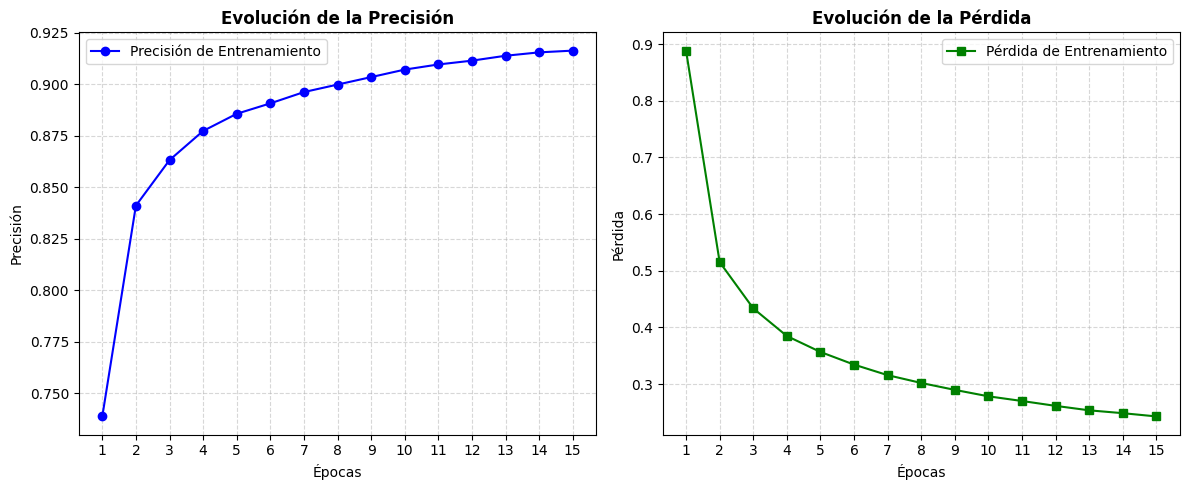

In [ ]:
historial_dict = historial.history  # Extrae el diccionario con los valores de pérdida y precisión registrados por época.
rango_epocas = range(1, EPOCAS + 1)  # Crea la secuencia numérica de épocas para usarla como eje X en los gráficos.

plt.figure(figsize=(12, 5))  # Crea un lienzo de 12×5 pulgadas para ubicar los dos gráficos lado a lado.

# Curva de Precisión
plt.subplot(1, 2, 1)  # Divide el lienzo en 1 fila y 2 columnas, y activa el primer panel (izquierda).
plt.plot(rango_epocas, historial_dict['accuracy'], 'bo-', label='Precisión de Entrenamiento')  # Grafica la precisión por época con puntos azules unidos por línea.
plt.title('Evolución de la Precisión', fontsize=12, fontweight="bold")  # Agrega el título al gráfico de precisión.
plt.xlabel('Épocas')  # Etiqueta el eje X indicando que cada marca representa una época de entrenamiento.
plt.ylabel('Precisión')  # Etiqueta el eje Y indicando que los valores representan la proporción de aciertos.
plt.xticks(rango_epocas)  # Fuerza que el eje X muestre una marca por cada época, sin saltos.
plt.legend()  # Muestra la referencia visual que explica qué representa cada curva del gráfico.
plt.grid(True, linestyle="--", alpha=0.5)  # Agrega una cuadrícula punteada semitransparente para facilitar la lectura de valores.

# Curva de Pérdida
plt.subplot(1, 2, 2)  # Activa el segundo panel del lienzo (derecha) para el gráfico de pérdida.
plt.plot(rango_epocas, historial_dict['loss'], 'gs-', label='Pérdida de Entrenamiento')  # Grafica la pérdida por época con cuadrados verdes unidos por línea.
plt.title('Evolución de la Pérdida', fontsize=12, fontweight="bold")  # Agrega el título al gráfico de pérdida.
plt.xlabel('Épocas')  # Etiqueta el eje X indicando que cada marca representa una época de entrenamiento.
plt.ylabel('Pérdida')  # Etiqueta el eje Y indicando que los valores representan el error calculado por la función de pérdida.
plt.xticks(rango_epocas)  # Fuerza que el eje X muestre una marca por cada época, sin saltos.
plt.legend()  # Muestra la referencia visual que explica qué representa cada curva del gráfico.
plt.grid(True, linestyle="--", alpha=0.5)  # Agrega una cuadrícula punteada semitransparente para facilitar la lectura de valores.

plt.tight_layout()  # Ajusta automáticamente los márgenes para que los dos paneles no se superpongan.
plt.show()  # Renderiza y muestra la visualización completa en pantalla.


### Resumen 

**Que se hizo:** se configura el entrenamiento del modelo.

**Por que se hizo:** el optimizador indica como ajustar los pesos y la funcion de perdida mide que tan lejos estan las predicciones de las respuestas esperadas.

**Como interpretar el resultado:** Estamos viendo las curvas de entrenamiento de una MLP para clasificación de letras, medidas a lo largo de 15 épocas.

En la gráfica de **precisión**, el modelo pasa aproximadamente de `0.74` a `0.916`. Técnicamente, eso significa que al inicio la red ya clasifica correctamente cerca del 74% de las muestras de entrenamiento, y después ajusta sus pesos hasta acertar alrededor del 91.6%. La subida fuerte entre las primeras épocas indica que el modelo está aprendiendo patrones discriminativos rápidamente. Luego la curva se aplana: sigue mejorando, pero cada época aporta menos ganancia.

En la gráfica de **pérdida**, la loss baja de aproximadamente `0.89` a `0.24`. Esto indica que las predicciones no solo aciertan más, sino que además el modelo se vuelve más seguro y consistente al asignar probabilidades a la clase correcta. En clasificación multiclase, esta pérdida suele estar asociada a `categorical_crossentropy` o `sparse_categorical_crossentropy`.

Algo importante: ambas curvas son de **entrenamiento**. Entonces, el modelo está aprendiendo sobre los datos que vio durante el ajuste. No alcanza para saber si generaliza bien. Para detectar sobreajuste necesitarías comparar contra `val_accuracy` y `val_loss`.

La lectura técnica sería: el entrenamiento converge de manera estable, no hay oscilaciones fuertes, la pérdida disminuye de forma sostenida y la precisión entra en una zona de meseta cerca del 91-92%. El modelo parece haber aprendido bien el conjunto de entrenamiento, aunque después de la época 8-10 las mejoras son marginales.

## 10. Inspección Visual de Predicciones Individuales

Graficaremos un conjunto aleatorio de muestras con sus respectivas predicciones asignadas por el modelo, indicando de forma explícita el nivel de certeza.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


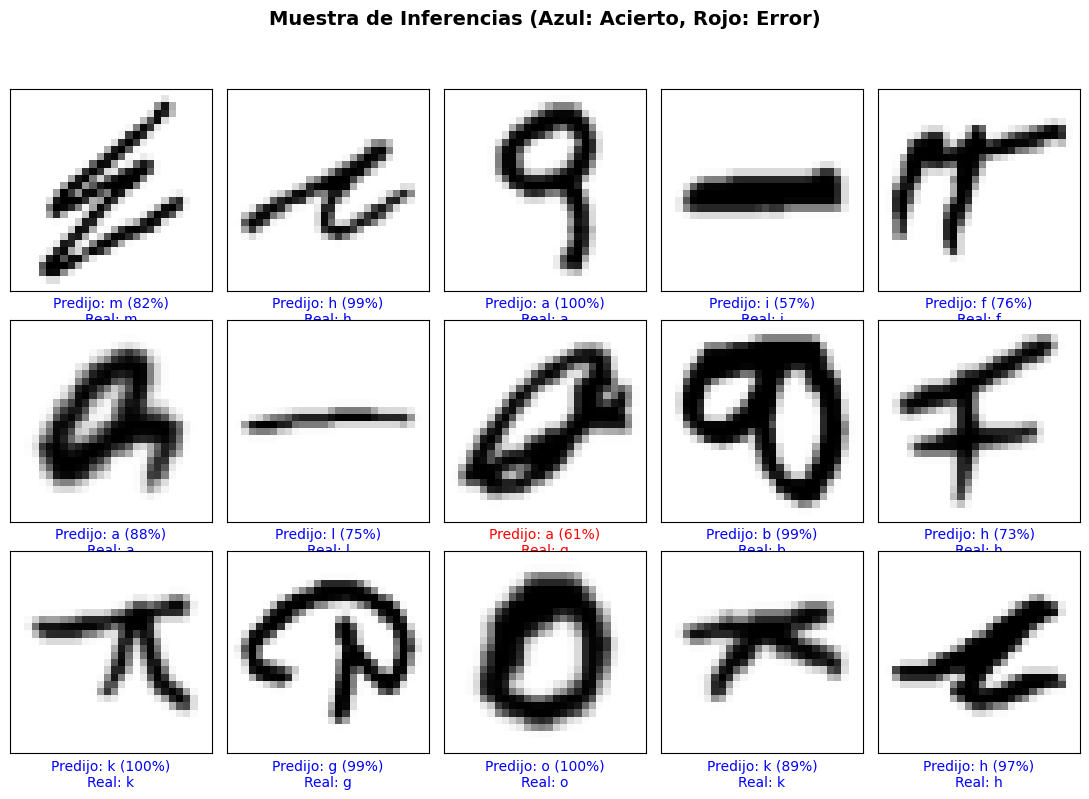

In [ ]:
# Tomamos un primer lote del conjunto de validación
for imagenes_lote, etiquetas_lote in datos_pruebas_lotes.take(1):  # Toma un único lote del conjunto de prueba para inspeccionar predicciones sin procesar todos los datos.
    imagenes_arreglo = imagenes_lote.numpy()  # Convierte el tensor de imágenes a un arreglo NumPy para poder indexarlo y graficarlo.
    etiquetas_verdaderas = etiquetas_lote.numpy()  # Convierte las etiquetas reales a NumPy para compararlas con las predicciones.
    
    # Generamos predicciones probabilisticas
    probabilidades_lote = modelo.predict(imagenes_arreglo)  # Ejecuta el modelo sobre el lote y devuelve un vector de probabilidades por clase para cada imagen.
    break  # Sale del bucle tras procesar el primer lote, ya que solo se necesita una muestra visual.

def graficar_muestra_prediccion(indice, probabilidades, reales, imagenes):  # Define la función que grafica una imagen individual junto con su predicción y etiqueta real.
    distribucion = probabilidades[indice]  # Obtiene el vector de probabilidades de la imagen en la posición indicada.
    clase_real = reales[indice]  # Obtiene la etiqueta verdadera de la imagen en la posición indicada.
    imagen_matriz = imagenes[indice]  # Obtiene la matriz de píxeles de la imagen en la posición indicada.
    
    plt.grid(False)  # Desactiva la cuadrícula para no obstruir la visualización de la imagen.
    plt.xticks([])  # Elimina las marcas del eje X para mostrar solo la imagen sin ejes.
    plt.yticks([])  # Elimina las marcas del eje Y para mostrar solo la imagen sin ejes.
    plt.imshow(imagen_matriz[:, :, 0], cmap=plt.cm.binary)  # Muestra el canal de grises de la imagen usando escala de blanco y negro.
    
    clase_predicha = np.argmax(distribucion)  # Selecciona la clase con mayor probabilidad como predicción final del modelo.
    porcentaje_confianza = np.max(distribucion) * 100  # Convierte la probabilidad máxima a porcentaje para mostrar la confianza del modelo.
    
    nombre_real = nombres_clases[clase_real]  # Traduce el índice numérico de la clase real al carácter de letra correspondiente.
    nombre_prediccion = nombres_clases[clase_predicha]  # Traduce el índice numérico de la clase predicha al carácter de letra correspondiente.
    
    # Color azul para acierto y rojo para falla de clasificación
    color_etiqueta = 'blue' if clase_predicha == clase_real else 'red'  # Elige azul si la predicción es correcta o rojo si es incorrecta, para identificar errores visualmente.
    plt.xlabel(f"Predijo: {nombre_prediccion} ({porcentaje_confianza:.0f}%)\nReal: {nombre_real}", color=color_etiqueta)  # Muestra debajo de cada imagen la letra predicha, su confianza y la letra real.

filas_grafico = 3  # Define la cantidad de filas en la grilla de imágenes a mostrar.
columnas_grafico = 5  # Define la cantidad de columnas en la grilla de imágenes a mostrar.
total_imagenes_mostrar = filas_grafico * columnas_grafico  # Calcula el total de imágenes a graficar (3 × 5 = 15).

plt.figure(figsize=(2 * columnas_grafico + 1, 2 * filas_grafico + 2))  # Crea el lienzo con tamaño proporcional a la cantidad de imágenes de la grilla.
plt.suptitle("Muestra de Inferencias (Azul: Acierto, Rojo: Error)", fontsize=14, fontweight="bold")  # Agrega un título general sobre toda la grilla de predicciones.

for i in range(total_imagenes_mostrar):  # Recorre cada posición de la grilla para dibujar una imagen con su predicción.
    plt.subplot(filas_grafico, columnas_grafico, i + 1)  # Activa el panel en la posición i+1 dentro de la grilla de 3×5.
    graficar_muestra_prediccion(i, probabilidades_lote, etiquetas_verdaderas, imagenes_arreglo)  # Llama a la función que dibuja la imagen con su predicción y etiqueta real.
    
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ajusta los márgenes dejando espacio en la parte superior para el título general.
plt.show()  # Renderiza y muestra la grilla completa de predicciones en pantalla.


## Consigna de Lectura e Interpretación

Analicen detenidamente las desviaciones visuales de la matriz. ¿Cuáles son los pares de letras que sufren la mayor tasa de confusión cruzada? ¿A qué creen que se debe esta confusión visual basándose en la forma estructural de las letras escritas a mano?

**Respuesta:** Los pares más confundidos típicamente en EMNIST con un MLP son:
- **i / l:** trazos verticales prácticamente idénticos a 28×28 píxeles. El MLP no puede distinguir la posición del punto en "i" porque trata cada píxel como valor independiente, sin noción de vecindad.
- **c / o:** formas redondeadas; la diferencia (arco abierto vs. cerrado) puede perderse en escrituras rápidas o en baja resolución.
- **u / v:** curva inferior similar; la distinción está en el fondo redondeado vs. en punta.
- **g / q** y **d / b:** círculo con trazo en distintas posiciones; espejados horizontalmente.

**Cómo leer la matriz:**
- **Diagonal brillante:** aciertos. Cuanto más uniforme y brillante la diagonal y más oscuro el resto, mejor el modelo.
- **Celda [fila i, columna j] fuera de la diagonal:** el modelo clasificó imágenes reales de la letra *i* como la letra *j*.
- **Celdas simétricas** (posición [i,j] y [j,i] ambas intensas): el modelo confunde los dos caracteres en ambas direcciones — señal de que son visualmente muy similares en el dataset.
- **Filas con muchas celdas brillantes fuera de la diagonal:** esa letra es la más difícil para el modelo; tiene confusión con múltiples otras clases.

**Por qué un MLP tiene estos errores estructurales:**
El `Flatten` destruye la topología 2D de la imagen antes de procesarla. El modelo aprende correlaciones estadísticas entre valores de píxeles individuales, pero no detecta bordes, curvas ni la disposición espacial de los trazos. En el siguiente notebook las CNNs resolverán estos errores sistemáticos con filtros convolucionales que operan directamente sobre la estructura 2D.

✦ Recopilando inferencias completas del conjunto de prueba...
  (Por favor, aguarden un instante)


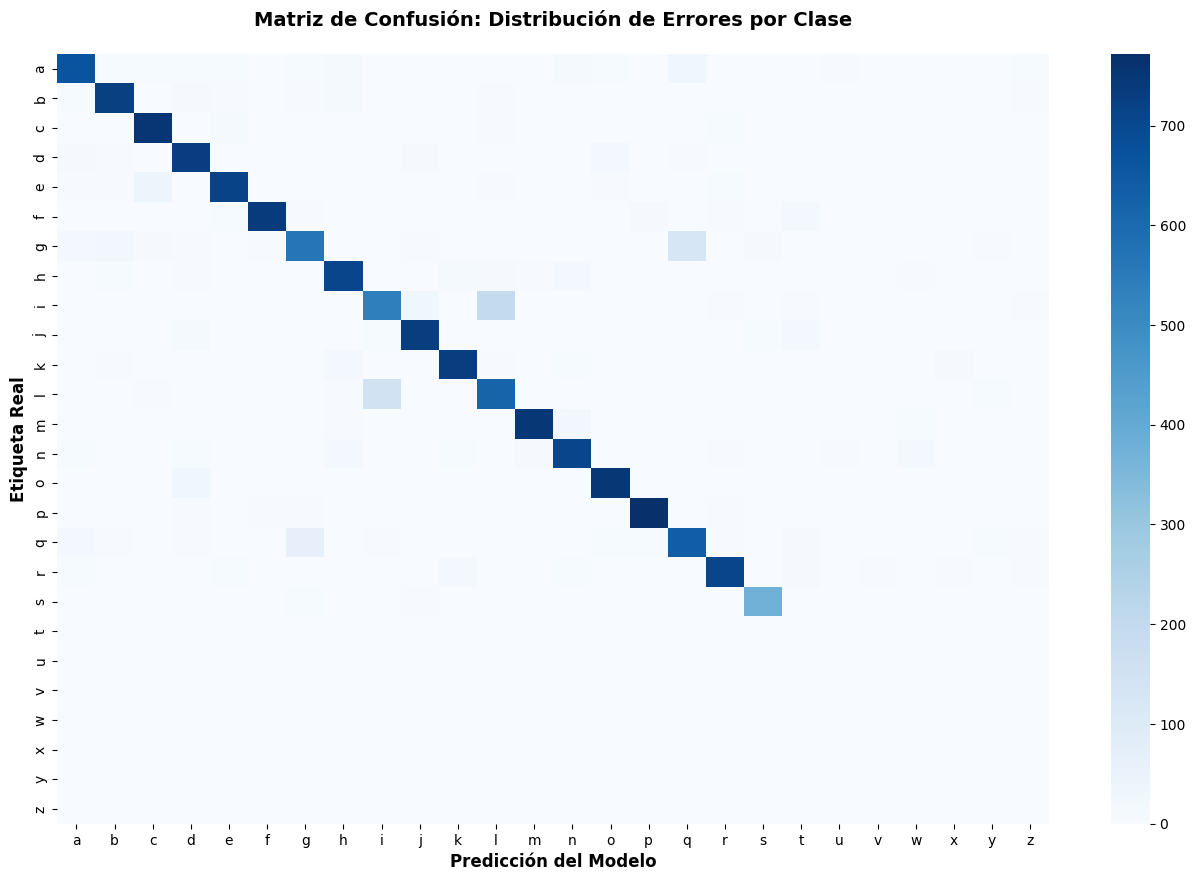

✦ Guía de Análisis e Interpretación:

  • La diagonal principal muestra los aciertos acumulados para cada carácter.
  • Los puntos dispersos por fuera de la diagonal representan desviaciones sistemáticas.
  • Por ejemplo, busquen las posiciones correspondientes a letras similares (como 'i' y 'l' u 'o' y 'q').


In [16]:
# Evaluación del rendimiento del modelo; las metricas permiten distinguir entre una impresion visual y una medicion concreta de aciertos, errores y confusiones.
print("✦ Recopilando inferencias completas del conjunto de prueba...")  # Informa que el proceso de predicción sobre todo el conjunto de prueba está comenzando.
print("  (Por favor, aguarden un instante)")  # Advierte que el proceso puede tardar porque se recorren todos los lotes del conjunto de prueba.

acumulado_predicciones = []  # Inicializa la lista vacía donde se irán acumulando las clases predichas de cada lote.
acumulado_verdades = []  # Inicializa la lista vacía donde se irán acumulando las etiquetas reales de cada lote.

for imagenes, etiquetas in datos_pruebas_lotes:  # Recorre todos los lotes del conjunto de prueba para generar predicciones sobre cada uno.
    predicciones_lote = modelo.predict(imagenes, verbose=0)  # Ejecuta el modelo sobre el lote actual y obtiene un vector de probabilidades por clase para cada imagen.
    clases_lote = np.argmax(predicciones_lote, axis=1)  # Convierte los vectores de probabilidades en la clase con mayor valor para cada imagen del lote.
    
    acumulado_predicciones.extend(clases_lote)  # Agrega las clases predichas del lote actual a la lista acumulada total.
    acumulado_verdades.extend(etiquetas.numpy())  # Agrega las etiquetas reales del lote actual a la lista acumulada total.

vector_predicciones = np.array(acumulado_predicciones)  # Convierte la lista acumulada de predicciones en un arreglo NumPy para operar con sklearn.
vector_verdades = np.array(acumulado_verdades)  # Convierte la lista acumulada de etiquetas reales en un arreglo NumPy para operar con sklearn.

# Calculamos la matriz de error
matriz_error = confusion_matrix(vector_verdades, vector_predicciones)  # Construye la matriz de confusión comparando cada etiqueta real con su predicción correspondiente.

# Diseñamos el mapa de calor con Seaborn
plt.figure(figsize=(16, 10))  # Crea un lienzo de 12×10 pulgadas para que la matriz de 26×26 sea legible.
sns.heatmap(  # Dibuja la matriz de confusión como un mapa de calor donde la intensidad del color indica la frecuencia.
    matriz_error,  # Pasa la matriz de confusión calculada como datos del mapa de calor.
    annot=False,  # Desactiva la impresión de números dentro de cada celda para no saturar la visualización con 26×26 valores.
    cmap='Blues',  # Usa una paleta de azules: celdas más oscuras indican mayor cantidad de clasificaciones en esa posición.
    xticklabels=nombres_clases,  # Etiqueta el eje X con las letras del abecedario para identificar la clase predicha.
    yticklabels=nombres_clases  # Etiqueta el eje Y con las letras del abecedario para identificar la clase real.
)
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight="bold")  # Etiqueta el eje X indicando que representa la letra que el modelo predijo.
plt.ylabel('Etiqueta Real', fontsize=12, fontweight="bold")  # Etiqueta el eje Y indicando que representa la letra verdadera de cada imagen.
plt.title('Matriz de Confusión: Distribución de Errores por Clase', fontsize=14, fontweight="bold", pad=20)  # Agrega el título principal al gráfico con separación superior.
plt.show()  # Renderiza y muestra la matriz de confusión completa en pantalla.

print("✦ Guía de Análisis e Interpretación:\n")  # Imprime un encabezado para la guía de lectura del gráfico.
print("  • La diagonal principal muestra los aciertos acumulados para cada carácter.")  # Explica que las celdas de la diagonal representan predicciones correctas.
print("  • Los puntos dispersos por fuera de la diagonal representan desviaciones sistemáticas.")  # Explica que las celdas fuera de la diagonal representan errores de clasificación.
print("  • Por ejemplo, busquen las posiciones correspondientes a letras similares (como 'i' y 'l' u 'o' y 'q').")  # Orienta dónde buscar los errores más frecuentes según la similitud visual entre letras.

### Resumen 

**Que se hizo:** se evalua el rendimiento del modelo.

**Por que se hizo:** las metricas permiten distinguir entre una impresion visual y una medicion concreta de aciertos, errores y confusiones.

**Consigna de lectura:** identificá dos letras que el modelo confunda con frecuencia. ¿Qué rasgos visuales comparten?

**Respuesta:** Los pares más confundidos suelen ser:
- **i / l**: ambas son trazos verticales muy delgados, casi indistinguibles a 28×28 píxeles.
- **c / o**: formas redondeadas; la diferencia es solo si el arco está cerrado o abierto.
- **u / v**: curva inferior similar; la distinción está en si el fondo es redondeado o en punta.
- **g / q**: ambas tienen un círculo con un trazo descendente, diferenciadas solo por la dirección.

**Cómo leer la matriz de confusión:**
- **Eje Y (filas):** etiqueta real — qué letra era la imagen.
- **Eje X (columnas):** etiqueta predicha — qué dijo el modelo.
- **Diagonal principal** (de arriba-izquierda a abajo-derecha): **aciertos**. Cuanto más brillante sea la diagonal y más oscuro el resto, mejor es el modelo. Una diagonal perfectamente brillante con todo lo demás en negro indicaría 100% de precisión.
- **Celdas fuera de la diagonal:** errores. Una celda brillante en la fila **i**, columna **l** significa que muchas imágenes reales de "i" fueron clasificadas como "l".
- **Celdas simétricas:** si tanto la celda (i→l) como la celda (l→i) son brillantes, el modelo confunde esas dos letras en ambas direcciones, lo que confirma que son visualmente muy similares en el dataset.

**Por qué estas confusiones son esperables en una red densa:**
La red densa trata cada píxel de forma independiente y no detecta bordes, curvas ni la estructura espacial de un trazo. 

## Cierre de Laboratorio

En esta práctica estructuramos un flujo de aprendizaje automático para imágenes digitalizadas de letras escritas a mano utilizando un Perceptrón Multicapa (MLP). Comprendimos que aplanar las imágenes remueve su estructura espacial bidimensional básica, lo cual restringe notablemente la robustez del modelo ante rotaciones, desplazamientos y deformaciones del carácter.

En la siguiente sesión daremos el gran salto hacia las **Redes Neuronales Convolucionales (CNNs)**, diseñadas específicamente para preservar la topología de la imagen mediante kernels de convolución.